# Imports

In [1]:
# 📌 Essential Libraries for Image Classification
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

# 📌 TensorFlow & Keras for CNN Model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization , GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras import layers


# 📌 Sklearn for Performance Metrics
# from sklearn.metrics import classification_report, confusion_matrix

# 📌 Suppress Warnings (optional)
import warnings
warnings.filterwarnings('ignore')

c:\Users\pmana\anaconda3\envs\hibiscus_cnn_model\lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 1.23.3)
  from scipy.stats import gaussian_kde


# GPU Check

In [2]:
from tensorflow.keras import mixed_precision

print("Available GPU's:", tf.config.list_physical_devices('GPU'))

keras.backend.clear_session()

Available GPU's: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Dataset Verfication

In [3]:
# Define dataset path (UPDATE with your actual dataset path)
dataset_path = "Dataset"

# List all classes (subdirectories)
classes = sorted(os.listdir(dataset_path))

# Print the number of images per class
print("Dataset Overview:\n----------------")
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")
    else:
        print(f"Skipping {class_name} (not a directory)")

Dataset Overview:
----------------
Madagascar_Periwinkle: 891 images
Song_of_India: 1668 images
Tulsi: 900 images


# View Sample Images

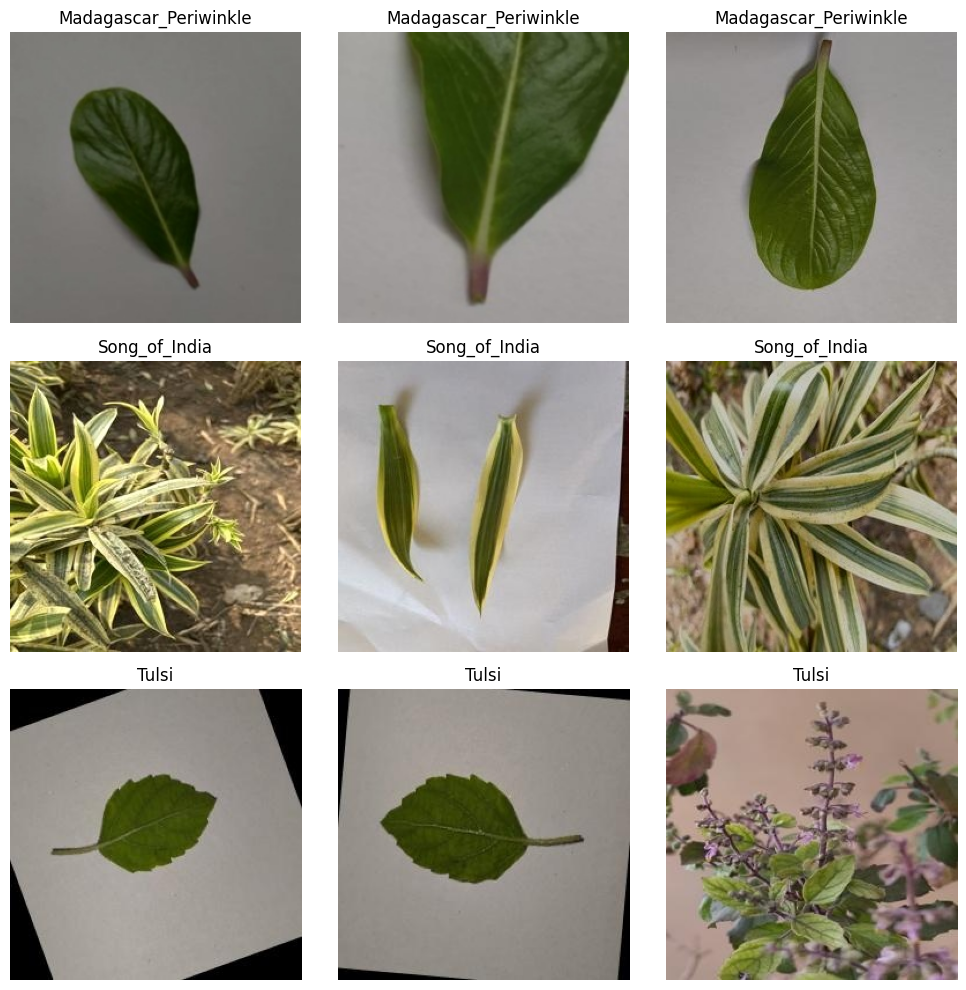

In [4]:
# Function to display sample images
def display_sample_images(dataset_path, classes, num_samples=3):
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(10, 10))
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        sample_images = random.sample(os.listdir(class_path), num_samples)  # Randomly select images
        
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)  # Open image
            
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            axes[i, j].set_title(class_name)
    
    plt.tight_layout()
    plt.show()

# Call the function
display_sample_images(dataset_path, classes)

# Data Preprocessing

In [5]:
IMG_SIZE = (224, 224)  # Keep the original size
BATCH_SIZE = 16  # Number of images per batch

# Only rescaling
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2
)

# Load Training Data (No Augmentation)
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

# Load Validation Data
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

Found 2768 images belonging to 3 classes.
Found 691 images belonging to 3 classes.


# Visualize Processed Images

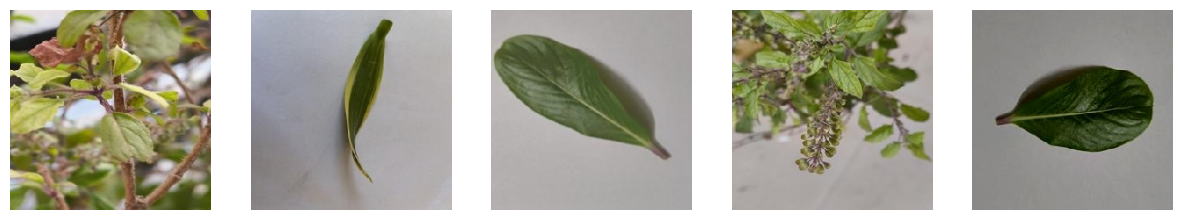

In [6]:
# Get a batch of images
sample_images, sample_labels = next(train_data)

# Display some augmented images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    axes[i].imshow(sample_images[i])
    axes[i].axis('off')

plt.show()

# CNN Architecture

In [7]:
# Build CNN Model
model = Sequential([
    # First Conv Layer
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Second Conv Layer
    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Third Conv Layer
    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten(),
    GlobalAveragePooling2D(),

    # Fully Connected Layer
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(3, activation='softmax')  # 3 classes
])

# Compile the model
optimizer = Adam(learning_rate=1.5e-5)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Model Summary
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 16)      448       
                                                                 
 batch_normalization (BatchN  (None, 222, 222, 16)     64        
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 32)      4640      
                                                                 
 batch_normalization_1 (Batc  (None, 109, 109, 32)     128       
 hNormalization)                                                 
                                                        

# Training the CNN Model

In [8]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

EPOCHS = 30 # Number of epochs

# Train the CNN model
history = model.fit(
    train_data,  
    validation_data=val_data,  
    epochs=EPOCHS,  # Adjust based on performance
    steps_per_epoch=len(train_data),  
    validation_steps=len(val_data), # Add early stopping callback
    callbacks=[reduce_lr],  # Reduce learning rate on plateau
)

# Final Training & Validation Accuracy and Loss
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")

Epoch 1/30
173/173 [==============================] - 13s 45ms/step - loss: 1.4479 - accuracy: 0.3125 - val_loss: 1.1816 - val_accuracy: 0.2605 - lr: 1.5000e-05
Epoch 2/30
173/173 [==============================] - 6s 37ms/step - loss: 1.0589 - accuracy: 0.4613 - val_loss: 1.2091 - val_accuracy: 0.2605 - lr: 1.5000e-05
Epoch 3/30
173/173 [==============================] - 6s 37ms/step - loss: 0.8783 - accuracy: 0.5975 - val_loss: 1.0797 - val_accuracy: 0.5137 - lr: 1.5000e-05
Epoch 4/30
173/173 [==============================] - 7s 38ms/step - loss: 0.7845 - accuracy: 0.6774 - val_loss: 0.9382 - val_accuracy: 0.5789 - lr: 1.5000e-05
Epoch 5/30
173/173 [==============================] - 6s 36ms/step - loss: 0.7061 - accuracy: 0.7439 - val_loss: 0.8457 - val_accuracy: 0.6151 - lr: 1.5000e-05
Epoch 6/30
173/173 [==============================] - 6s 37ms/step - loss: 0.6553 - accuracy: 0.7811 - val_loss: 0.7869 - val_accuracy: 0.6382 - lr: 1.5000e-05
Epoch 7/30
173/173 [===================

# Model Evaluation

In [9]:
# model.save("Indian_Plant_Leaves_Model.h5")
val_loss, val_acc = model.evaluate(val_data)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

44/44 [==============================] - 1s 19ms/step - loss: 0.2078 - accuracy: 0.9624
Validation Accuracy: 0.9624
Validation Loss: 0.2078


# Graphs of Training & Validation Accuracy/Loss

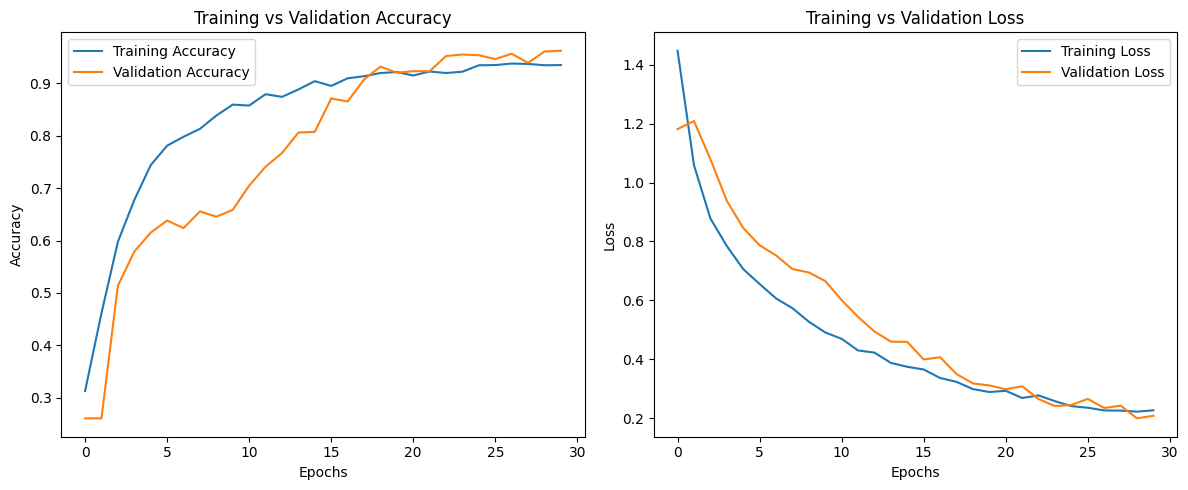

In [10]:
# Extract values from training history
epochs_range = range(len(history.history['accuracy']))
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(False)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss',)
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()


# Image Classification

In [8]:
from tensorflow.keras.preprocessing import image
import gradio as gr

# Load the model
model = tf.keras.models.load_model("Indian_Plant_Leaves_Model.h5")

# Get class labels
class_labels = list(train_data.class_indices.keys())
print("Class Labels:", class_labels)

# Define image size (same as training size)
IMG_SIZE = (224, 224)

# Function to preprocess and predict
def predict_image(img):
    img = img.resize(IMG_SIZE)  # Resize to match model input
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Expand dims

    # Predict
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])  # Get highest probability class

    return class_labels[predicted_class]  # Return class name

# Create Gradio interface
iface = gr.Interface(
    fn=predict_image,  # Function to call
    inputs=gr.Image(type="pil"),  # Image input
    outputs="text",  # Output text
    title="Indian Plant Leaves Classification",
    description="Upload an image of an indian plant leaf, and the model will predict its type.",
)

# Launch the app
iface.launch()

Class Labels: ['Madagascar_Periwinkle', 'Song_of_India', 'Tulsi']
* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.
